In [2]:
import numpy as np
from nilearn.image import load_img
import matplotlib.pyplot as plt
import scipy.stats
from scipy.stats import spearmanr, pearsonr
import pandas as pd
import scipy.io
import pickle
import os
import warnings
from nilearn.image import load_img, new_img_like
from scipy.stats import pearsonr, zscore, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, surface
from nilearn.plotting import plot_surf_stat_map
warnings.filterwarnings("ignore", category=RuntimeWarning, message="Mean of empty slice")
from statsmodels.tools.sm_exceptions import ConvergenceWarning
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

def conv_r2z(r):
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))
def conv_z2r(z):
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

## check how brain similarity track behavioral similarity
def nanspearmanr(tc1,tc2):
    nanid1 = np.where(np.isnan(tc1))
    nanid2 = np.where(np.isnan(tc2))
    nanid = np.union1d(nanid1,nanid2)
    tc1 = np.delete(tc1,nanid)
    tc2 = np.delete(tc2,nanid)
    rval,pval = spearmanr(tc1,tc2)
    return rval,pval

## compute neural synchrony
def nanpearsonr(tc1,tc2):
    nanid1 = np.where(np.isnan(tc1))
    nanid2 = np.where(np.isnan(tc2))
    nanid = np.union1d(nanid1,nanid2)
    tc1 = np.delete(tc1,nanid)
    tc2 = np.delete(tc2,nanid)
    rval,pval = pearsonr(tc1,tc2)
    return rval,pval

def onetail_p(real, null):
    p = (np.sum(null>=real)) / (1+len(null))
    # print(str(np.sum(null>=real))+' among '+str(len(null))+' null has higher r value than actual prediction')
    return p

def twotail_p(real, null):
    p = (1 + np.sum(abs(null)>=abs(real))) / (1+len(null))
    # print(str(np.sum(null>=real))+' among '+str(len(null))+' null has higher r value than actual prediction')
    return p

os.chdir('/Users/jinke/Desktop/socialaha_github/') # change to your folder path
directory = './socialaha-collab'

event_idxs = pd.read_csv(directory + '/socialaha-fMRI/socialaha_groupscene.csv')
def rearrange(group_id,run_id,brain):
    current_indices = event_idxs[event_idxs['run'] == run_id]['g'+str(group_id)+'.char'].tolist()
    sorted_order = np.argsort(current_indices)
    rearranged_brain = brain[sorted_order]
    return rearranged_brain

def rearrange_new(group_id,run_id,brain): # by character
    current_indices = event_idxs[event_idxs['run'] == run_id]['g'+str(group_id)+'.char'].tolist()
    # print(current_indices)
    sorted_order = np.argsort(current_indices)
    rearranged_brain = brain[sorted_order]
    if 5 in current_indices:
        rearranged_brain4 = []
        for i in range(4):
            if i in [1,3]:
                this_run = np.nanmean(rearranged_brain[[i, 4], :], axis=0)
            else:
                this_run = rearranged_brain[i]
            rearranged_brain4.append(this_run)
    else:
        duplicates = [x for x in set(current_indices) if current_indices.count(x) > 1]
        if len(duplicates) == 0:
            pass
        else:
            rearranged_brain4 = []
            for i in range(1,4+1):
                if duplicates[0] == i:
                    this_run = np.nanmean(rearranged_brain[[i, i-1], :], axis=0)
                else:
                    this_run = rearranged_brain[i]
                rearranged_brain4.append(this_run)
    return np.array(rearranged_brain4)

def char_order(group_id,run_id):
    current_indices = event_idxs[event_idxs['run'] == run_id]['g'+str(group_id)+'.char'].tolist()
    current_indices.sort()
    return current_indices

# reference image: MNI template
def niftimask(nroi_cor, nroi_sub, directory):
    cortical = directory+'/template/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-02_atlas-Schaefer2018_desc-'+str(nroi_cor)+'Parcels17Networks_dseg.nii.gz'
    if nroi_sub==16: subcortical = directory+'/template/Tian2020MSA_v1.1_3T_Subcortex-Only/Tian_Subcortex_S1_3T_2009cAsym.nii.gz'
    elif nroi_sub==32: subcortical = directory+'/template/Tian2020MSA_v1.1_3T_Subcortex-Only/Tian_Subcortex_S2_3T_2009cAsym.nii.gz'
    elif nroi_sub == 50: subcortical = directory + '/template/Tian2020MSA_v1.1_3T_Subcortex-Only/Tian_Subcortex_S3_3T_2009cAsym.nii.gz'
    elif nroi_sub == 54: subcortical = directory + '/template/Tian2020MSA_v1.1_3T_Subcortex-Only/Tian_Subcortex_S4_3T_2009cAsym.nii.gz'
    mask_cor = load_img(cortical).dataobj[:]
    mask_sub = load_img(subcortical).dataobj[:]

    for i1 in range(mask_sub.shape[0]):
        for i2 in range(mask_sub.shape[1]):
            for i3 in range(mask_sub.shape[2]):
                if mask_sub[i1,i2,i3]>0:
                    mask_sub[i1,i2,i3] = mask_sub[i1,i2,i3] + nroi_cor

    id = np.where(np.multiply(mask_cor, mask_sub)>0)
    mask = mask_cor + mask_sub
    mask[id[0],id[1],id[2]] = 0
    return mask
nroi_cor, nroi_sub = 100, 16
nroi = nroi_cor + nroi_sub
mask = niftimask(nroi_cor, nroi_sub, directory)

niteration = 10000

# testing how neural ISC mediates the relationship between pre- and post-impressions

In [3]:
thoughts_similarity = np.load('./data/beh/similarity/impressions_byrun_bychar.npy', allow_pickle=True).item() # ngroup*nrun - nchar*nsubjpairs
neuralISC = np.load('./data/brain/similarity/neuralISC_byevent.npy', allow_pickle=True).item() # nroi*ngroup*nrun - nsubjpairs

In [4]:
# prepare the similarity matrices - brain
brain_isc = []
for roi in range(1,nroi+1):
    this_roi = []
    for groupid in range(1,3+1):
        this_group = []
        for run in range(10):
            this_brain = neuralISC[roi,groupid,run]
            if run == 6: # python convertion, refering to the 7th run
                this_run = np.nanmean(this_brain,axis=0)
                this_run = np.vstack([this_run,this_run,this_run,this_run])
            else:
                this_run = rearrange_new(groupid,run+1,this_brain) # python convertion, id in csv starts from 1
            this_group.append(this_run)
        this_group = np.concatenate(this_group)
        this_roi.append(np.array(this_group))
    brain_isc.append(this_roi)

# brain_isc[roi][group] - nscene*nsubjpair

In [5]:
# prepare the similarity matrices - thoughts
thought_sim = []
for groupid in range(1,3+1):
    this_group = []
    for run in range(10):
        this_group.append(thoughts_similarity[groupid,run+1])
    this_group = np.concatenate(this_group)
    thought_sim.append(np.array(this_group))

In [6]:
rows = []
for groupid in range(3):
    thought_sim_before = thought_sim[groupid][:-4]
    thought_sim_after  = thought_sim[groupid][4:]

    n_scenes, n_pairs = thought_sim_before.shape

    # pre-load all ROI brain sims for this condition into a 3D array: (roi, scenes, pairs)
    brain_all = np.stack([brain_isc[roi][groupid][4:] for roi in range(116)], axis=0)

    for scene in range(n_scenes):
        for pair in range(n_pairs):
            row = {
                "scene": scene,
                "pair": pair,
                "condition": groupid,
                "thought_before": thought_sim_before[scene, pair],
                "thought_after": thought_sim_after[scene, pair],
            }
            # add 116 ROI columns
            for roi in range(116):
                row[f"brain_sim_{roi}"] = brain_all[roi, scene, pair]
            rows.append(row)

df = pd.DataFrame(rows)

In [7]:
df.to_csv("./results/IS-RSA/mediation.csv", index=False)

# the modeling is done in step05_mediation.R

In [9]:
results = pd.read_csv('./results/IS-RSA/mediation_results_all_rois.csv')
acme = results['ACME'].tolist()

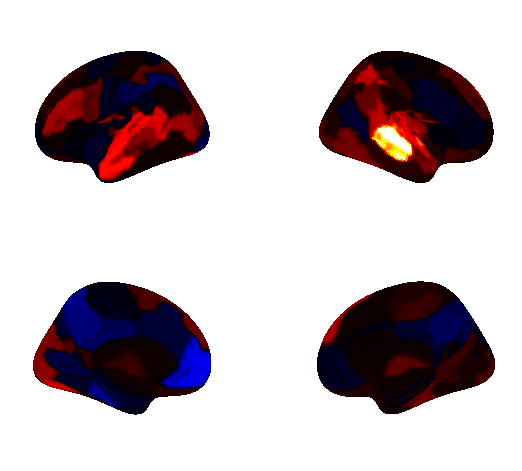

In [10]:
ref_img = load_img(directory+'/template/tpl-MNI152NLin2009cAsym_res-02_atlas-Schaefer2018_desc-100Parcels17Networks_dseg.nii.gz')
brain = np.zeros((mask.shape[0],mask.shape[1],mask.shape[2]))
for i in range(brain.shape[0]):
    for j in range(brain.shape[1]):
        for k in range(brain.shape[2]):
            idx = int(mask[i,j,k])
            idx = idx -1
            brain[i,j,k] = acme[idx]
brain_map = new_img_like(ref_img,brain)

# volume to surface reconstruction
fsaverage = datasets.fetch_surf_fsaverage(mesh='fsaverage5')
surface_left = surface.vol_to_surf(brain_map, fsaverage.pial_left)
surface_right = surface.vol_to_surf(brain_map, fsaverage.pial_right)

sns.set_context('paper')
fig, ((a, b),(c, d)) = plt.subplots(2, 2, subplot_kw={'projection': '3d'})

plot_surf_stat_map(fsaverage.infl_left, surface_left, hemi='left',
                    view='lateral', bg_map=fsaverage.sulc_left,  cmap='cold_hot',
                    vmin=-0.006, vmax=0.006, colorbar=False, axes=a)
plot_surf_stat_map(fsaverage.infl_right, surface_right, hemi='right',
                    view='lateral', bg_map=fsaverage.sulc_right, cmap='cold_hot',
                     vmin=-0.006, vmax=0.006, colorbar=False, axes=b)
plot_surf_stat_map(fsaverage.infl_left, surface_left, hemi='left',
                    view='medial',bg_map=fsaverage.sulc_left, cmap='cold_hot',
                     vmin=-0.006, vmax=0.006, colorbar=False, axes=c)
plot_surf_stat_map(fsaverage.infl_right, surface_right, hemi='right',
                    view='medial',bg_map=fsaverage.sulc_right, cmap='cold_hot',
                    vmin=-0.006, vmax=0.006, colorbar=False, axes=d)
plt.savefig('./results/figures/mediation_ACME.png',dpi = 1000)
plt.tight_layout()

Shuffling subject pair - These are significant ROIs (corrected-p < 0.05):
[98]


/opt/anaconda3/lib/python3.12/site-packages/nilearn/plotting/img_plotting.py:92: RuntimeWarning: All-NaN slice encountered
  stat_map_min = np.nanmin(stat_map_data)
/opt/anaconda3/lib/python3.12/site-packages/nilearn/plotting/img_plotting.py:95: RuntimeWarning: All-NaN slice encountered
  stat_map_max = np.nanmax(stat_map_data)


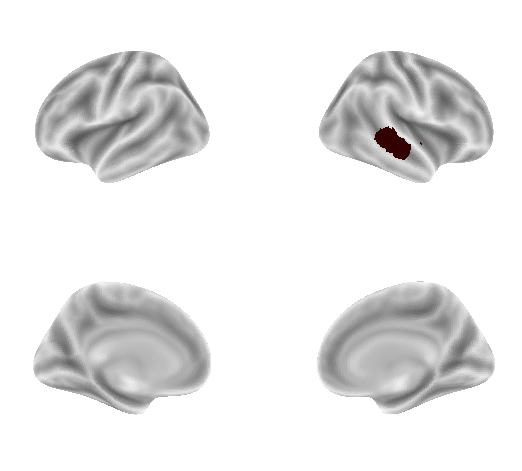

In [11]:
pvals = results['ACME_p'].tolist()

# correct for multiple comparison
from statsmodels.stats.multitest import multipletests
alpha = 0.05
rejected, pvals_corrected_05, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
pvals_corrected_05 = [round(i,4) for i in pvals_corrected_05]
sig_rois = np.where(np.array(pvals_corrected_05) < alpha)
# sig_rois = [i+1 for i in sig_rois]
print('Shuffling subject pair - These are significant ROIs (corrected-p < 0.05):')
print(sig_rois[0])


ref_img = load_img(directory+'/template/tpl-MNI152NLin2009cAsym_res-02_atlas-Schaefer2018_desc-100Parcels17Networks_dseg.nii.gz')
brain = np.zeros((mask.shape[0],mask.shape[1],mask.shape[2]))
for i in range(brain.shape[0]):
    for j in range(brain.shape[1]):
        for k in range(brain.shape[2]):
            idx = int(mask[i,j,k])
            idx = idx -1
            if idx in sig_rois[0]:
                brain[i,j,k] = acme[idx]
            else:
                brain[i,j,k] = np.nan
brain_map = new_img_like(ref_img,brain)

# volume to surface reconstruction
fsaverage = datasets.fetch_surf_fsaverage(mesh='fsaverage5')
surface_left = surface.vol_to_surf(brain_map, fsaverage.pial_left)
surface_right = surface.vol_to_surf(brain_map, fsaverage.pial_right)

sns.set_context('paper')
fig, ((a, b),(c, d)) = plt.subplots(2, 2, subplot_kw={'projection': '3d'})

plot_surf_stat_map(fsaverage.infl_left, surface_left, hemi='left',
                    view='lateral', bg_map=fsaverage.sulc_left,  cmap='cold_hot',
                    vmin=-0.10, vmax=0.10, colorbar=False, axes=a)
plot_surf_stat_map(fsaverage.infl_right, surface_right, hemi='right',
                    view='lateral', bg_map=fsaverage.sulc_right, cmap='cold_hot',
                    vmin=-0.10, vmax=0.10, colorbar=False, axes=b)
plot_surf_stat_map(fsaverage.infl_left, surface_left, hemi='left',
                    view='medial',bg_map=fsaverage.sulc_left, cmap='cold_hot',
                    vmin=-0.10, vmax=0.10, colorbar=False, axes=c)
plot_surf_stat_map(fsaverage.infl_right, surface_right, hemi='right',
                    view='medial',bg_map=fsaverage.sulc_right, cmap='cold_hot',
                    vmin=-0.10, vmax=0.10, colorbar=False, axes=d)
plt.savefig('./results/figures/mediation_ACME_sig_rois.png',dpi = 1000)
plt.tight_layout()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


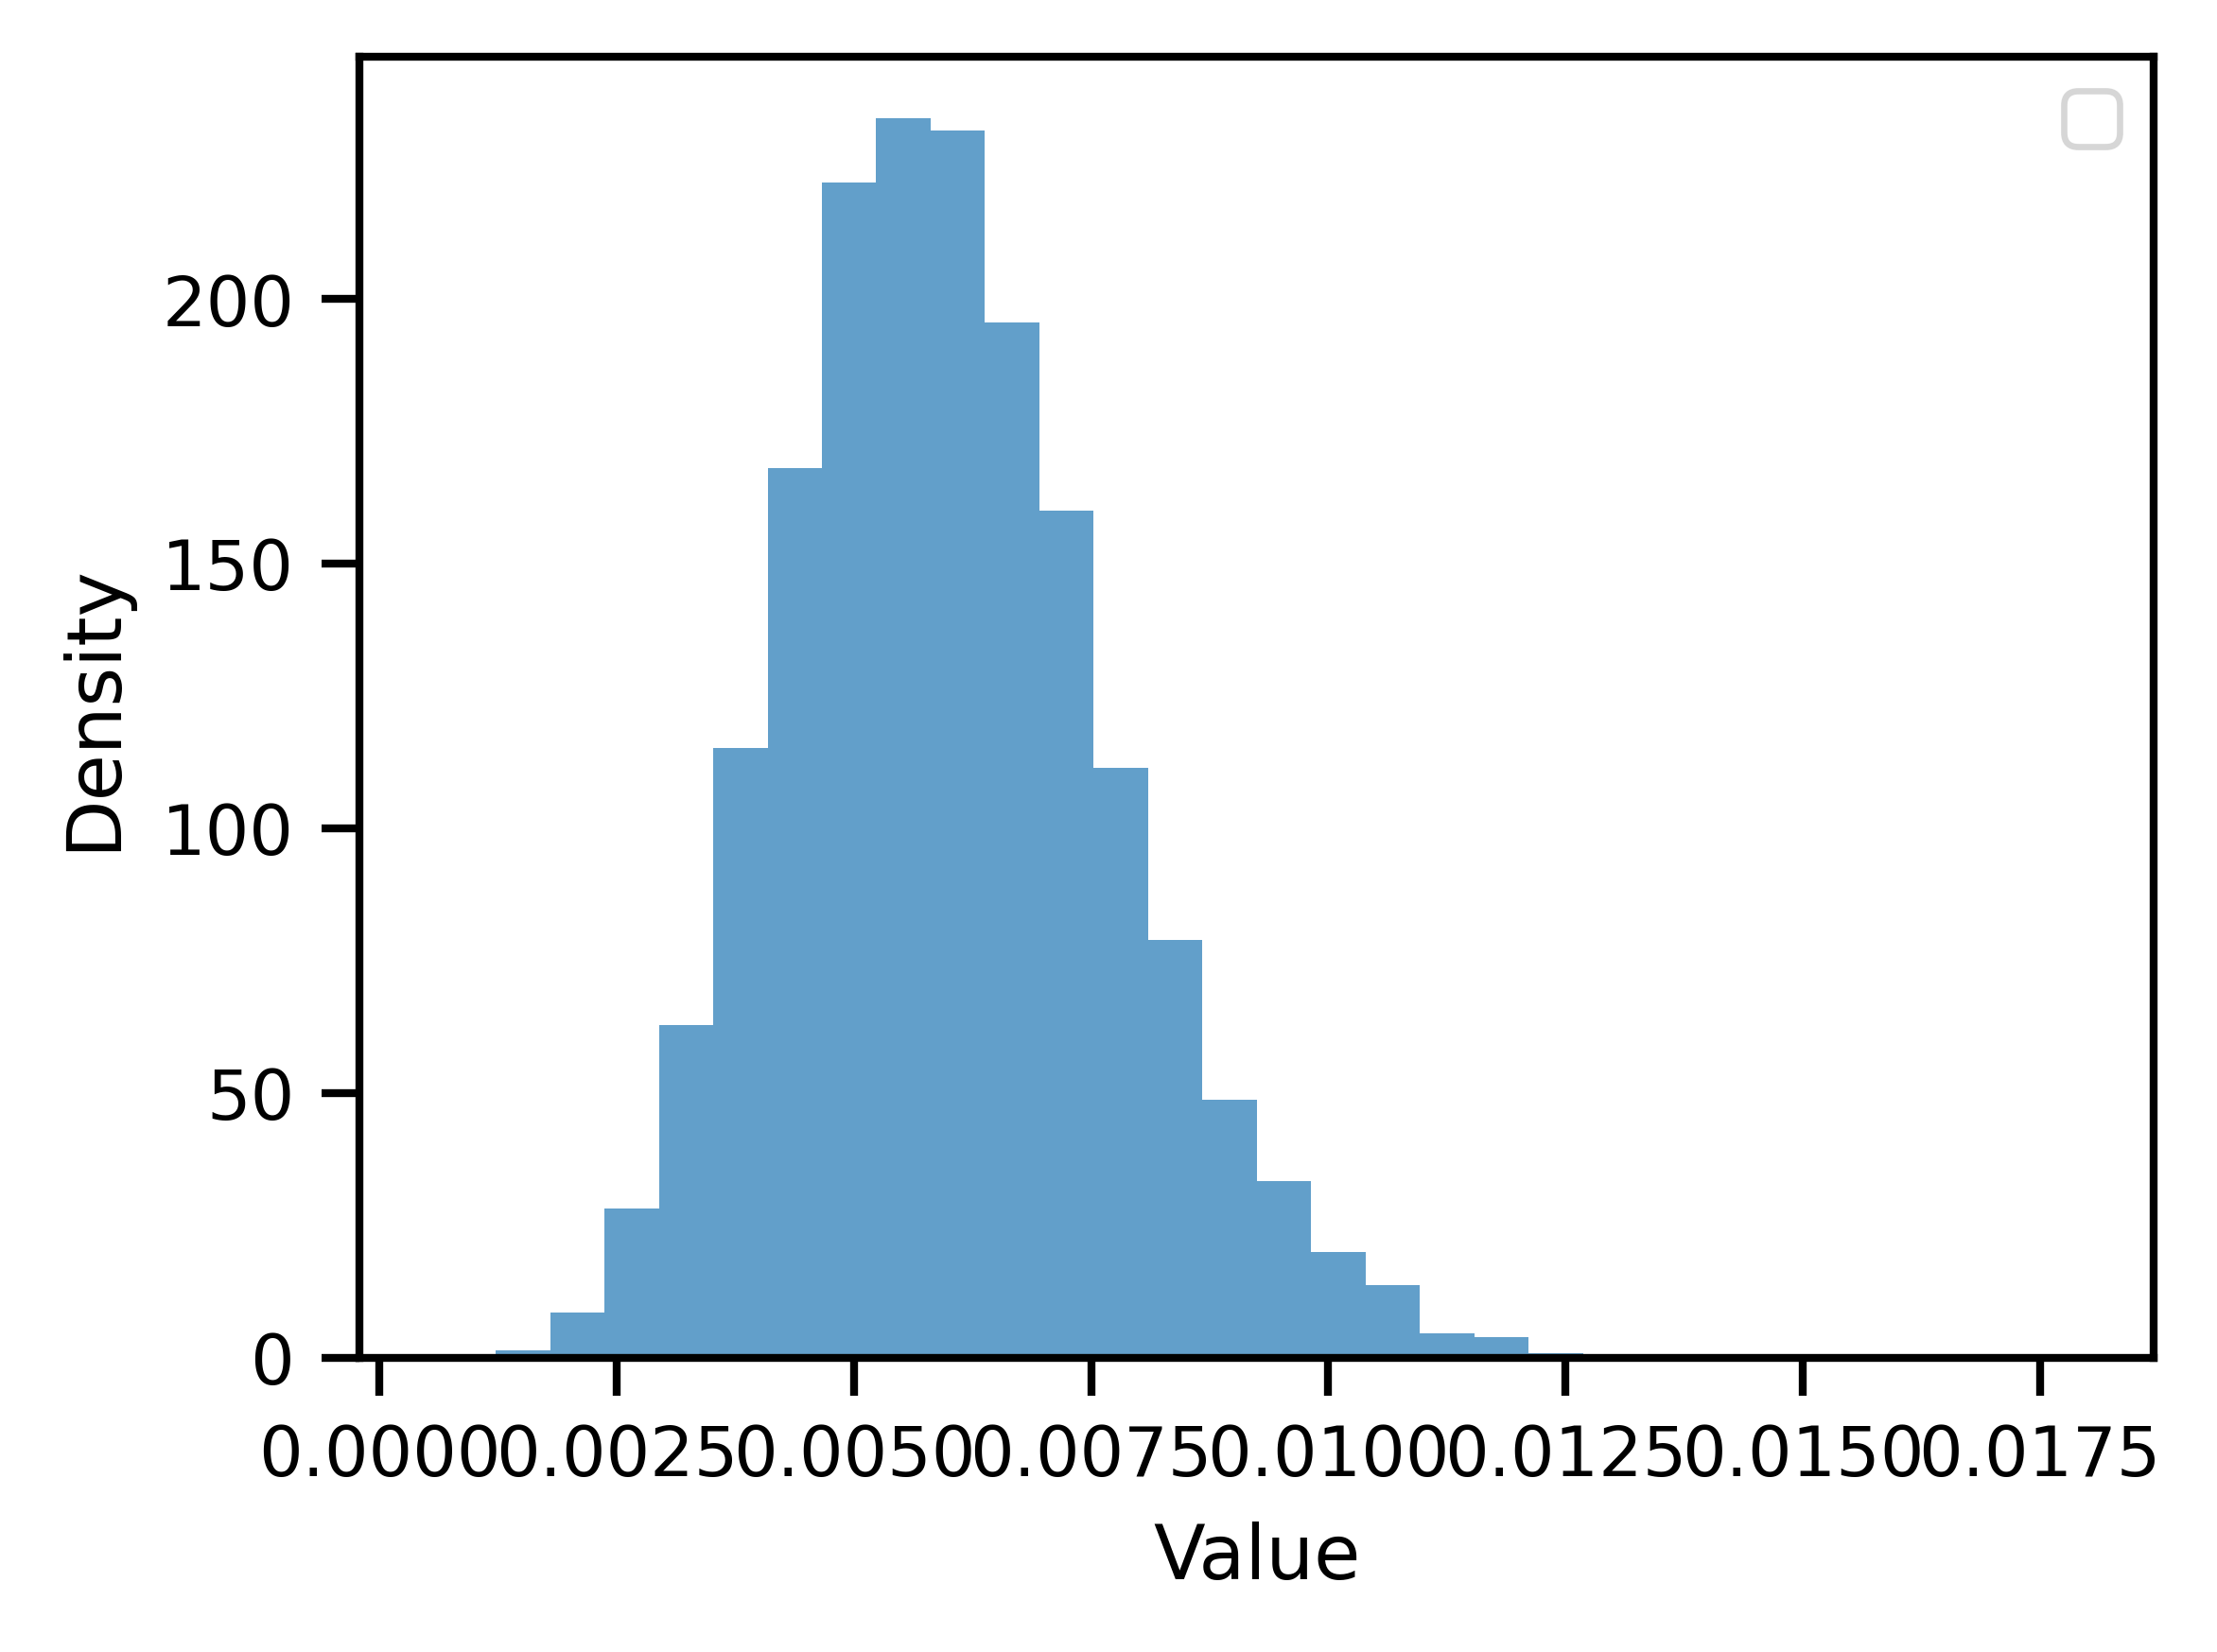

In [14]:
data = pd.read_csv('./results/IS-RSA/ACME_null_roi98.csv')['ACME_null'].tolist()
mean = np.mean(data)
median = np.median(data)

plt.figure(figsize=(4, 3), dpi=600)
plt.hist(data, bins=30, density=True, alpha=0.7)
# plt.axvline(mean, linestyle='--', linewidth=2, label='Mean')
# plt.axvline(median, linestyle=':', linewidth=2, label='Median')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('./results/figures/mediation_STS.png',dpi = 1000)
plt.show()

In [15]:
median

0.0058830708551786005